# Frequency Analysis for verbs & Zipf's Law

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict
from scipy.stats import spearmanr, linregress
from nltk.corpus import stopwords
import re
import spacy
nlp = spacy.load("de_core_news_sm")

In [2]:
df = pd.read_csv("../data/wikipedia_text.csv", sep = ",")

In [3]:
stop_words = set(stopwords.words("german")) | set(stopwords.words("english"))

In [4]:
def tokenize(text: str, pos_filter: set = None) -> list:
    # Überschriften entfernen
    text = re.sub(r"={1,6}[^=]+={1,6}", "", text)

    doc = nlp(text[:100_000])  # spacy hat ein Zeichenlimit
    tokens = []
    for token in doc:
        if pos_filter and token.pos_ not in pos_filter:
            continue
        w = token.lemma_.lower()  # Grundform statt Flexion
        if w not in stop_words and len(w) > 2 and w.isalpha():
            tokens.append(w)
    return tokens

In [12]:
def collect_corpora(df):
    corpora = {"männlich": [], "weiblich": []}
    for _, row in df.iterrows():
        gender = row["genderLabel"].strip().lower()
        if gender in corpora:
            tokens = tokenize(row["text"], pos_filter={"VERB"})
            corpora[gender].extend(tokens)
    return corpora

## Frequency analysis & Zipf fit

In [13]:
def word_frequencies(tokens: list) -> dict:
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w: c / total for w, c in counts.items()}


def fit_zipf(freq_dict: dict):
    """
    Fit P(f) ~ f^-alpha via log-log linear regression on rank vs frequency.
    Returns (alpha, r_squared).
    """
    sorted_freqs = sorted(freq_dict.values(), reverse=True)
    ranks = np.arange(1, len(sorted_freqs) + 1)
    log_r = np.log(ranks)
    log_f = np.log(sorted_freqs)
    slope, intercept, r, _, _ = linregress(log_r, log_f)
    return -slope, r**2

In [14]:
# Rank correlation between genders
def rank_correlation(freq_m: dict, freq_f: dict):
    """Spearman rank correlation on shared vocabulary."""
    common = set(freq_m) & set(freq_f)
    if len(common) < 10:
        return None, None, 0
    words = list(common)
    fm = [freq_m[w] for w in words]
    ff = [freq_f[w] for w in words]
    rho, pval = spearmanr(fm, ff)
    return rho, pval, len(common)

In [15]:
# Pointwise Mutual Information (PMI)

def compute_pmi(corpora: dict, top_n: int = 30) -> dict:
    """
    PMI(word, gender) = log[ P(word, gender) / (P(word) * P(gender)) ]
    Positive PMI = word is more associated with that gender.
    """
    all_tokens = corpora["männlich"] + corpora["weiblich"]
    total = len(all_tokens)
    n_male = len(corpora["männlich"])
    n_female = len(corpora["weiblich"])

    p_gender = {"männlich": n_male / total, "weiblich": n_female / total}

    all_counts = Counter(all_tokens)
    gender_counts = {g: Counter(corpora[g]) for g in ("männlich", "weiblich")}

    pmi = defaultdict(dict)
    for word, global_count in all_counts.items():
        if global_count < 120:
            continue
        p_word = global_count / total
        for gender in ("männlich", "weiblich"):
            gc = gender_counts[gender].get(word, 0)
            p_word_gender = gc / total
            if p_word_gender == 0:
                pmi[gender][word] = -np.inf
            else:
                pmi[gender][word] = math.log2(p_word_gender / (p_word * p_gender[gender]))

    top_male   = sorted(pmi["männlich"],   key=lambda w: pmi["männlich"][w],   reverse=True)[:top_n]
    top_female = sorted(pmi["weiblich"], key=lambda w: pmi["weiblich"][w], reverse=True)[:top_n]
    return {"männlich": {w: pmi["männlich"][w]   for w in top_male},
            "weiblich": {w: pmi["weiblich"][w] for w in top_female},
            "all": pmi}

In [16]:
# 5. Visualisations
# ---------------------------------------------------------------------------

COLORS = {"male": "#4C72B0", "female": "#DD8452"}


def plot_pmi(pmi_data: dict, top_n: int = 20):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, gender, color in zip(axes, ("männlich", "weiblich"),
                                 (COLORS["male"], COLORS["female"])):
        words = list(pmi_data[gender].keys())[:top_n]
        scores = [pmi_data[gender][w] for w in words]
        y_pos = np.arange(len(words))
        ax.barh(y_pos, scores, color=color, alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("PMI (bits)")
        ax.set_title(f"Top words associated with {gender} scientists")
        ax.axvline(0, color="black", linewidth=0.8)
    plt.suptitle("Pointwise Mutual Information by Gender", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_rank_scatter(freq_m: dict, freq_f: dict):
    common = set(freq_m) & set(freq_f)
    words = list(common)
    fm = np.array([freq_m[w] for w in words])
    ff = np.array([freq_f[w] for w in words])

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(np.log10(fm), np.log10(ff), alpha=0.2, s=5, color="#888888")

    # Annotate a few interesting words
    interesting = sorted(common, key=lambda w: abs(freq_m[w] - freq_f[w]),
                         reverse=True)[:12]
    for w in interesting:
        ax.annotate(w, (np.log10(freq_m[w]), np.log10(freq_f[w])),
                    fontsize=7, alpha=0.8)

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "r--", linewidth=0.8, label="y = x")
    ax.set_xlabel("log₁₀(frequency) — male scientists")
    ax.set_ylabel("log₁₀(frequency) — female scientists")
    ax.set_title("Word Frequency Rank Scatter (shared vocabulary)")
    ax.legend()
    plt.tight_layout()
    plt.show()

Wikipedia Gender Bias Analyser for Scientists

Corpus sizes — Männlich: 6,135 tokens, Weiblich: 4,533 tokens

Rank correlation (shared vocab, n=520):
  ρ = 0.705  p = 2.27e-79

Top 10 male-associated words (PMI):
  wählen               +0.171
  promovieren          +0.139
  studieren            +0.130
  erhalten             +0.128
  veröffentlichen      +0.103
  arbeiten             -0.005
  forschen             -0.133
  lehren               -0.160
  leiten               -0.262

Top 10 female-associated words (PMI):
  leiten               +0.292
  lehren               +0.192
  forschen             +0.162
  arbeiten             +0.006
  veröffentlichen      -0.152
  erhalten             -0.193
  studieren            -0.198
  promovieren          -0.213
  wählen               -0.270


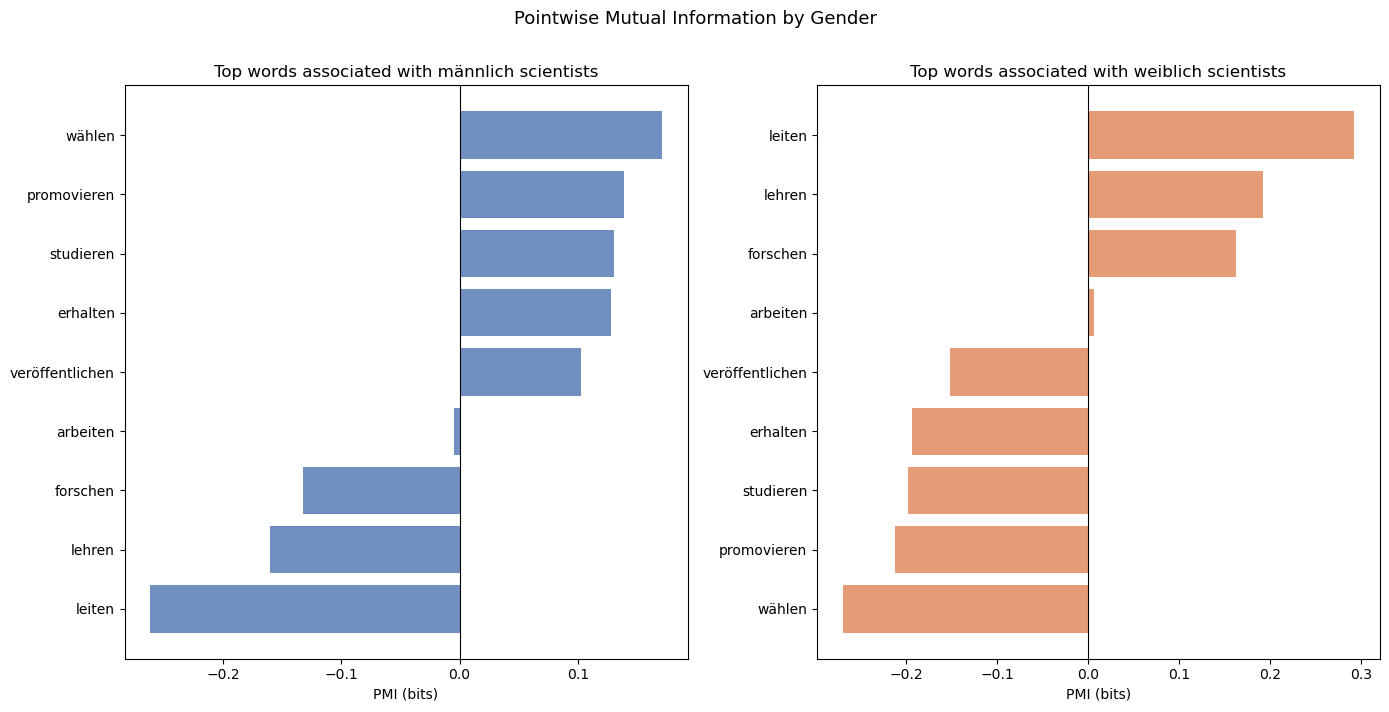

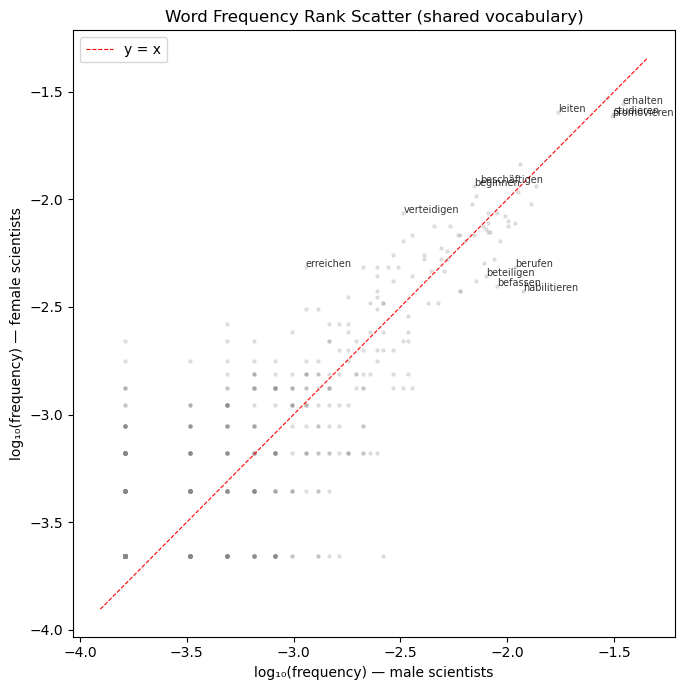

In [17]:
def main():
    print("=" * 60)
    print("Wikipedia Gender Bias Analyser for Scientists")
    print("=" * 60)

    corpora = collect_corpora(df=df)
    print(f"\nCorpus sizes — Männlich: {len(corpora['männlich']):,} tokens, "
          f"Weiblich: {len(corpora['weiblich']):,} tokens")

    freq_m = word_frequencies(corpora["männlich"])
    freq_f = word_frequencies(corpora["weiblich"])

    rho, pval, n_common = rank_correlation(freq_m, freq_f)
    print(f"\nRank correlation (shared vocab, n={n_common:,}):")
    print(f"  ρ = {rho:.3f}  p = {pval:.2e}")

    pmi_data = compute_pmi(corpora, top_n=30)

    print("\nTop 10 male-associated words (PMI):")
    for w, s in list(pmi_data["männlich"].items())[:10]:
        print(f"  {w:<20} {s:+.3f}")

    print("\nTop 10 female-associated words (PMI):")
    for w, s in list(pmi_data["weiblich"].items())[:10]:
        print(f"  {w:<20} {s:+.3f}")

    plot_pmi(pmi_data, top_n=20)
    plot_rank_scatter(freq_m, freq_f)

if __name__ == "__main__":
    main()